# 💳 Credit Card Fraud Detection
**Author:** Muhammad Hanzla  
**Dataset:** Credit Card Fraud Detection — ULB Machine Learning Group (Kaggle)  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · Imbalanced-learn · SHAP  
**Goal:** Detect fraudulent transactions (0.17% of data) with maximum recall and minimal false negatives.

---
## Pipeline
`Load Data` → `EDA` → `Feature Engineering` → `Isolation Forest` → `SMOTE + RF` → `XGBoost` → `SHAP` → `Threshold Tuning` → `Business Impact`

> 📌 **Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
> ⚠️ **Note:** Features V1–V28 are PCA-transformed for confidentiality. `Time`, `Amount`, and `Class` are original.

<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 35px; border-radius: 12px; text-align: center; border: 1px solid #1e40af;">

<h2 style="color: #60a5fa; margin-bottom: 5px;">👨‍💻 About the Author</h2>
<h3 style="color: #f1f5f9; margin-top: 0;">Muhammad Hanzla</h3>

<p style="color: #94a3b8; font-size: 15px; max-width: 600px; margin: 0 auto 20px auto;">A passionate <strong style="color: #38bdf8;">Data Scientist</strong> with a keen interest in machine learning, data analysis, and building intelligent solutions. Always exploring new datasets, uncovering hidden patterns, and turning raw data into meaningful insights.</p>

<hr style="border: none; border-top: 1px solid #1e40af; margin: 20px auto; width: 60%;">

<p style="color: #64748b; font-size: 13px; margin-bottom: 15px; letter-spacing: 1px; text-transform: uppercase;">🔗 Connect &amp; Collaborate</p>

<p style="text-align: center;"><a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📧 Email</a> <a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📊 Kaggle</a> <a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>💻 GitHub</a> <a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>💼 LinkedIn</a> <a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; background:#0f2744; padding: 8px 16px; border-radius: 20px; text-decoration: none; font-size: 14px; border: 1px solid #1e40af; display: inline-block; margin: 5px;'>📷 Instagram</a></p>

<p style="color: #475569; font-size: 12px; margin-top: 25px;">💡 <em>"Data is the new oil — and I love refining it."</em></p>

</div>

## 1. Install & Import Libraries

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install',
                'xgboost','imbalanced-learn','shap','-q'], check=False)
print('✅ Packages ready')

✅ Packages ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing        import StandardScaler, RobustScaler
from sklearn.ensemble             import (RandomForestClassifier,
                                           IsolationForest,
                                           GradientBoostingClassifier)
from sklearn.linear_model         import LogisticRegression
from sklearn.pipeline             import Pipeline
from sklearn.metrics              import (classification_report, confusion_matrix,
                                           roc_auc_score, roc_curve,
                                           precision_recall_curve,
                                           average_precision_score,
                                           ConfusionMatrixDisplay, f1_score,
                                           accuracy_score, matthews_corrcoef)
from imblearn.over_sampling       import SMOTE, ADASYN
from imblearn.under_sampling      import RandomUnderSampler
from imblearn.combine             import SMOTETomek
from imblearn.pipeline            import Pipeline as ImbPipeline
from xgboost                      import XGBClassifier
import shap

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('✅ All libraries loaded')

✅ All libraries loaded


## 2. Load Dataset
The **ULB Credit Card Fraud** dataset — 284,807 transactions over 2 days in September 2013 by European cardholders.

In [3]:
PATH = '/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv'

df = pd.read_csv(PATH)
print(f'Shape        : {df.shape}')
print(f'Columns      : {list(df.columns)}')
print(f'Memory usage : {df.memory_usage().sum()/1e6:.1f} MB')
print()
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100
print(f'Legitimate   : {legit_count:,}  ({100-fraud_pct:.3f}%)')
print(f'Fraud        : {fraud_count:,}  ({fraud_pct:.3f}%)')
print(f'Imbalance    : {legit_count/fraud_count:.0f}:1  (legit:fraud)')
df.head(3)

Shape        : (284807, 31)
Columns      : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Memory usage : 70.6 MB

Legitimate   : 284,315  (99.827%)
Fraud        : 492  (0.173%)
Imbalance    : 578:1  (legit:fraud)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 3. Exploratory Data Analysis
### 3.1 Class Imbalance & Amount Distribution

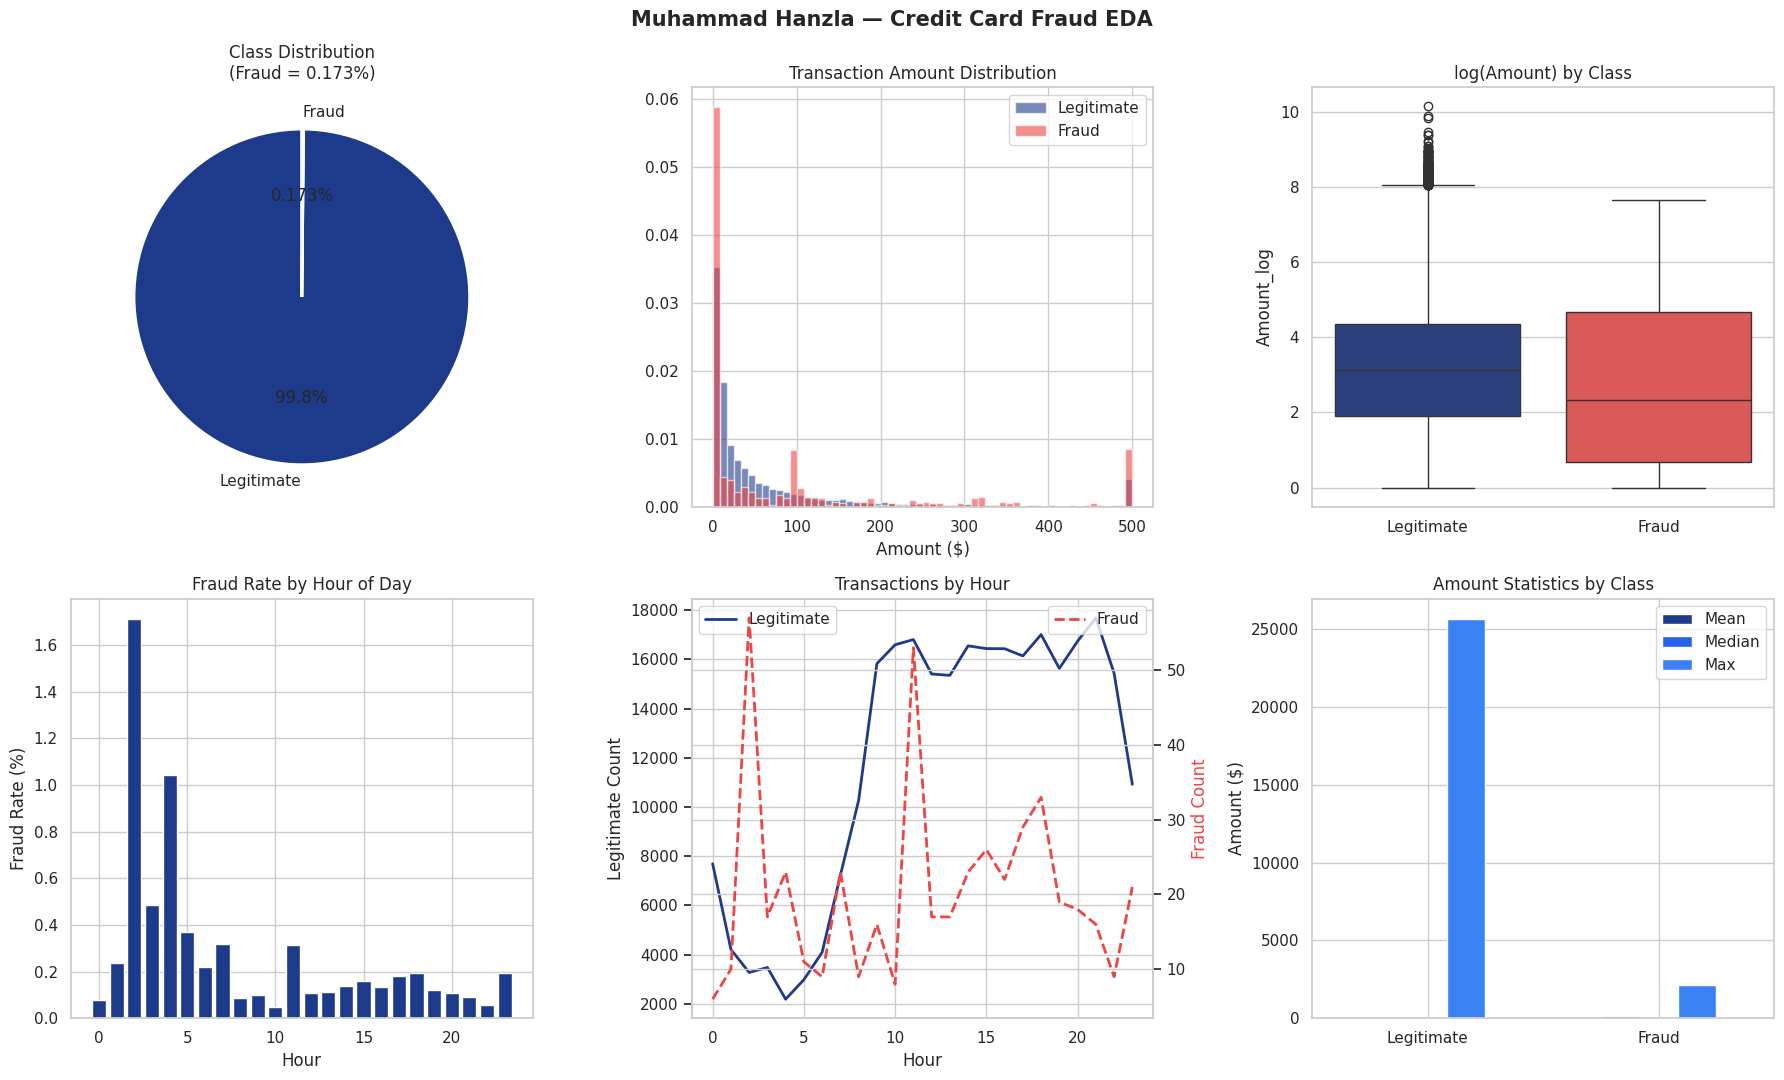

EDA Part 1 saved ✅


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Muhammad Hanzla — Credit Card Fraud EDA', fontsize=15, fontweight='bold')

# Class imbalance
counts = df['Class'].value_counts()
axes[0,0].pie([legit_count, fraud_count],
               labels=['Legitimate','Fraud'],
               colors=['#1e3a8a','#ef4444'],
               autopct=lambda p: f'{p:.3f}%' if p < 1 else f'{p:.1f}%',
               wedgeprops={'edgecolor':'white','linewidth':2},
               startangle=90)
axes[0,0].set_title(f'Class Distribution\n(Fraud = {fraud_pct:.3f}%)')

# Amount distribution
for cls, clr, lbl in [(0,'#1e3a8a','Legitimate'),(1,'#ef4444','Fraud')]:
    vals = df[df['Class']==cls]['Amount'].clip(0, 500)
    axes[0,1].hist(vals, bins=60, alpha=0.6, color=clr, label=lbl, density=True)
axes[0,1].set_title('Transaction Amount Distribution')
axes[0,1].set_xlabel('Amount ($)'); axes[0,1].legend()

# Amount boxplot
df_box = df.copy()
df_box['Class_label'] = df_box['Class'].map({0:'Legitimate',1:'Fraud'})
df_box['Amount_log']  = np.log1p(df_box['Amount'])
sns.boxplot(data=df_box, x='Class_label', y='Amount_log', ax=axes[0,2],
            palette={'Legitimate':'#1e3a8a','Fraud':'#ef4444'})
axes[0,2].set_title('log(Amount) by Class')
axes[0,2].set_xlabel('')

# Fraud by hour of day
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
hourly_fraud = df.groupby('Hour')['Class'].agg(['sum','count'])
hourly_fraud['rate'] = hourly_fraud['sum'] / hourly_fraud['count'] * 100
axes[1,0].bar(hourly_fraud.index, hourly_fraud['rate'],
               color='#1e3a8a', edgecolor='white')
axes[1,0].set_title('Fraud Rate by Hour of Day')
axes[1,0].set_xlabel('Hour'); axes[1,0].set_ylabel('Fraud Rate (%)')

# Transaction count by hour
txn_by_hour = df.groupby(['Hour','Class']).size().unstack(fill_value=0)
txn_by_hour[0].plot(ax=axes[1,1], color='#1e3a8a', label='Legitimate', lw=2)
ax2 = axes[1,1].twinx()
txn_by_hour[1].plot(ax=ax2, color='#ef4444', label='Fraud', lw=2, ls='--')
axes[1,1].set_title('Transactions by Hour')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('Legitimate Count')
ax2.set_ylabel('Fraud Count', color='#ef4444')
axes[1,1].legend(loc='upper left'); ax2.legend(loc='upper right')

# Amount stats comparison
stats = df.groupby('Class')['Amount'].describe()[['mean','50%','max']]
stats.index = ['Legitimate','Fraud']
stats.plot(kind='bar', ax=axes[1,2], color=['#1e3a8a','#2563eb','#3b82f6'],
            edgecolor='white')
axes[1,2].set_title('Amount Statistics by Class')
axes[1,2].set_ylabel('Amount ($)')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(['Mean','Median','Max'])

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA Part 1 saved ✅')

### 3.2 PCA Feature Distributions (V1–V28)

Top discriminating features: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9']


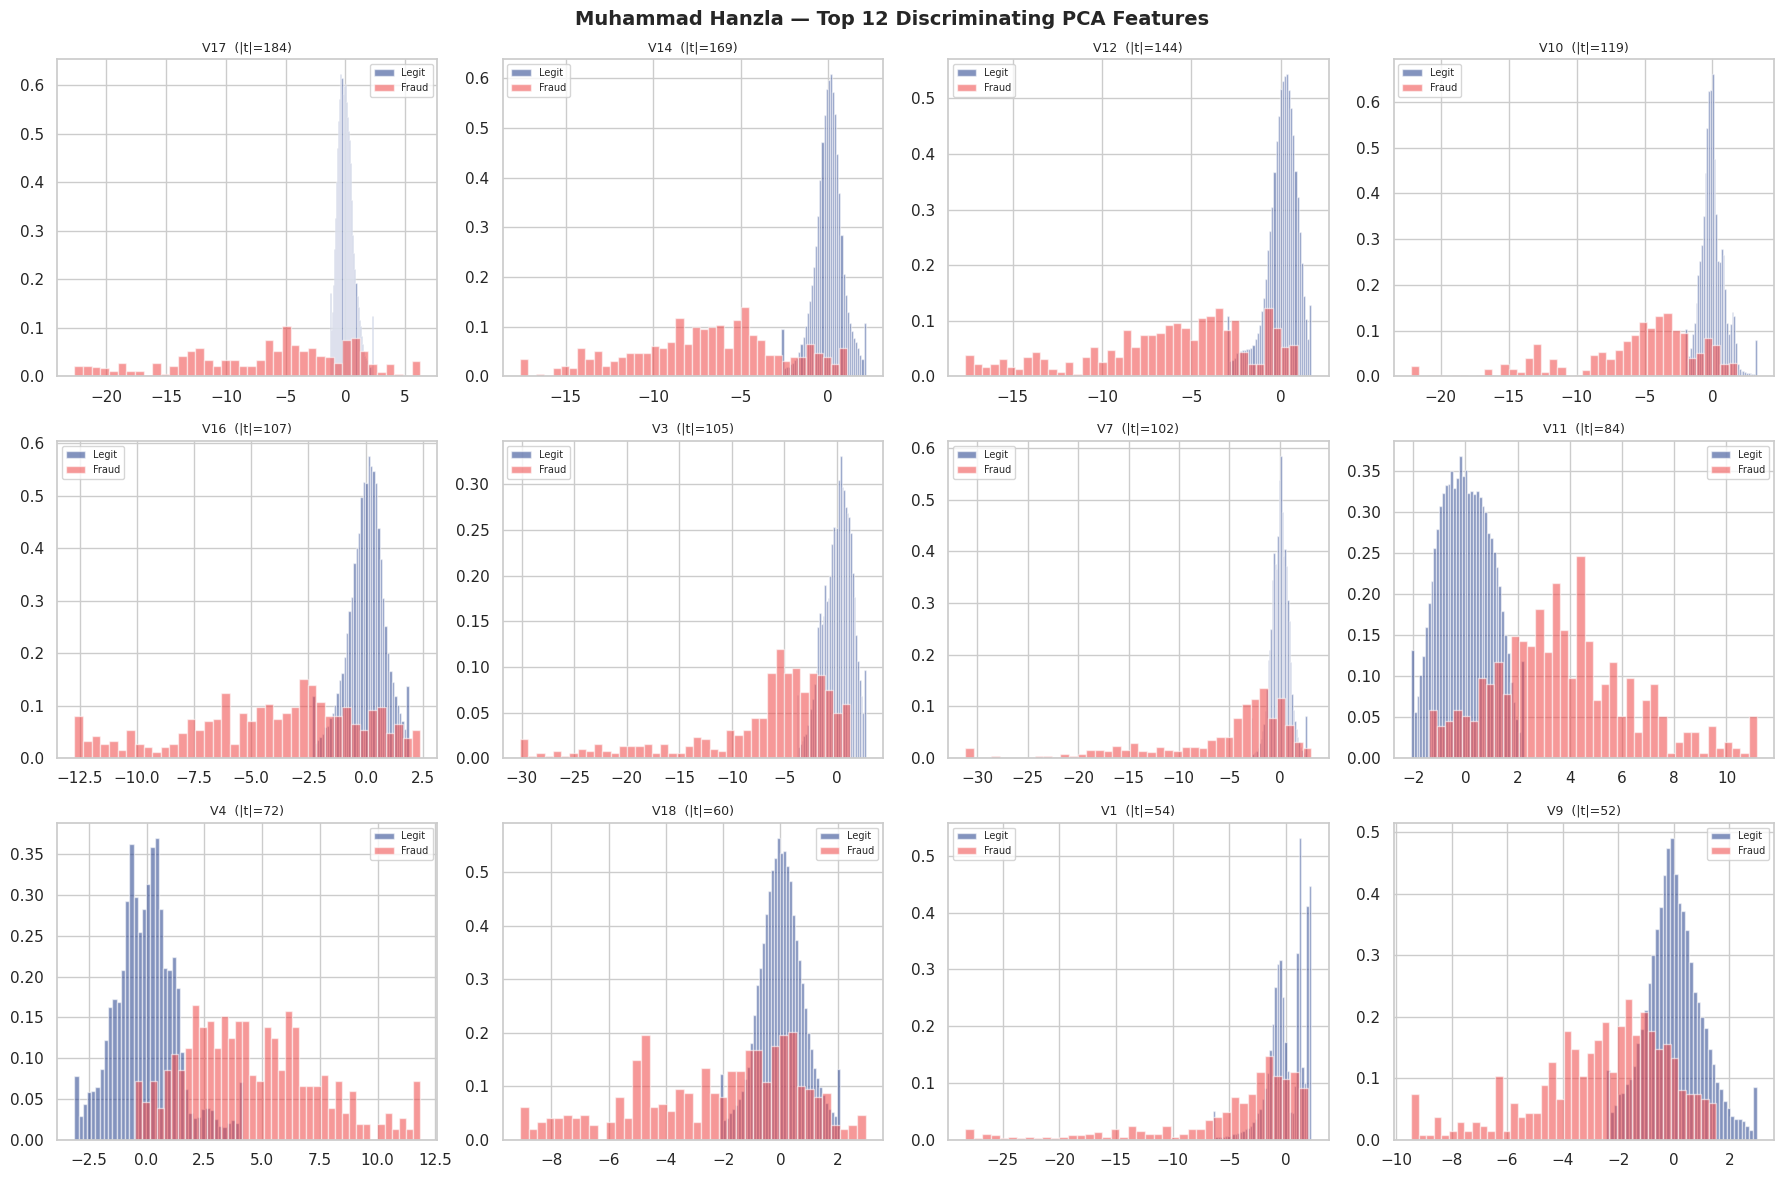

PCA features saved ✅


In [5]:
# Most discriminating PCA features by t-test
from scipy.stats import ttest_ind

v_cols = [f'V{i}' for i in range(1,29)]
t_stats = {}
for col in v_cols:
    legit_vals = df[df['Class']==0][col]
    fraud_vals = df[df['Class']==1][col]
    t, p = ttest_ind(legit_vals, fraud_vals)
    t_stats[col] = abs(t)

top_features = sorted(t_stats, key=t_stats.get, reverse=True)[:12]
print(f'Top discriminating features: {top_features}')

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Muhammad Hanzla — Top 12 Discriminating PCA Features', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top_features):
    for cls, clr, lbl in [(0,'#1e3a8a','Legit'),(1,'#ef4444','Fraud')]:
        vals = df[df['Class']==cls][feat]
        ax.hist(vals.clip(vals.quantile(0.01), vals.quantile(0.99)),
                bins=40, alpha=0.55, color=clr, label=lbl, density=True)
    ax.set_title(f'{feat}  (|t|={t_stats[feat]:.0f})', fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('02_pca_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA features saved ✅')

### 3.3 Correlation Heatmap

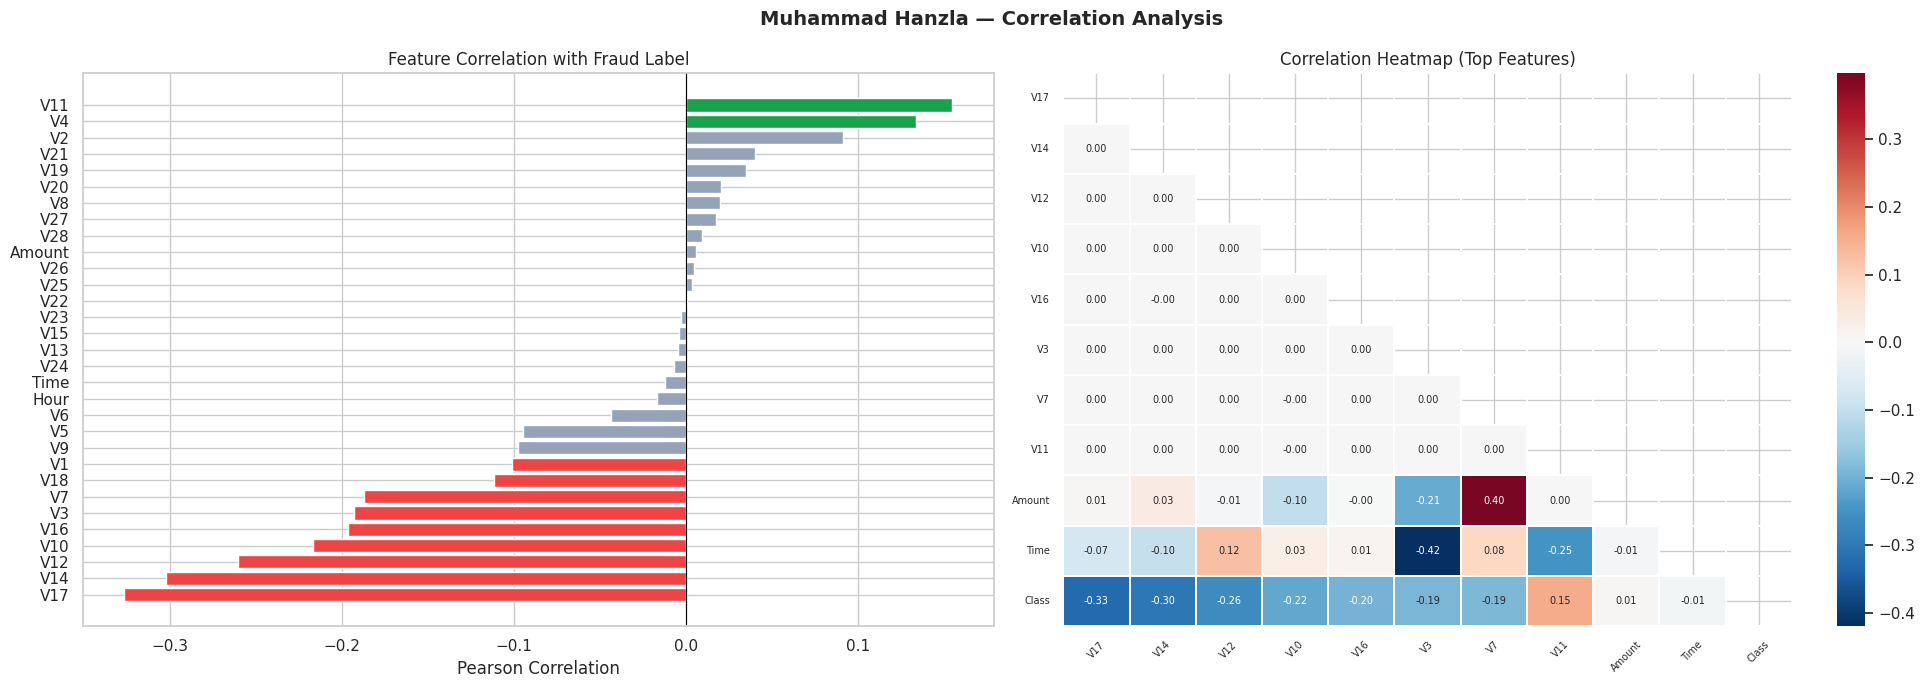

Correlation analysis saved ✅


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Muhammad Hanzla — Correlation Analysis', fontsize=14, fontweight='bold')

# Feature correlations with Class
corr_class = df.corr()['Class'].drop('Class').sort_values()
colors_corr = ['#ef4444' if v < -0.1 else '#16a34a' if v > 0.1 else '#94a3b8'
                for v in corr_class]
axes[0].barh(corr_class.index, corr_class.values, color=colors_corr, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Feature Correlation with Fraud Label')
axes[0].set_xlabel('Pearson Correlation')

# Subset heatmap (top features + Amount + Time)
sub_feats = top_features[:8] + ['Amount','Time','Class']
corr_sub  = df[sub_feats].corr()
mask      = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, ax=axes[1], annot=True, fmt='.2f',
             cmap='RdBu_r', mask=mask, center=0,
             annot_kws={'size':7}, linewidths=0.3)
axes[1].set_title('Correlation Heatmap (Top Features)')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('03_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation analysis saved ✅')

## 4. Feature Engineering

In [7]:
df_model = df.copy()

# Log-transform Amount (heavy right skew)
df_model['Amount_log']   = np.log1p(df_model['Amount'])
df_model['Amount_sqrt']  = np.sqrt(df_model['Amount'])

# Time-based features
df_model['Hour']         = (df_model['Time'] / 3600).astype(int) % 24
df_model['IsNight']      = df_model['Hour'].isin([22,23,0,1,2,3,4]).astype(int)
df_model['IsHighAmount'] = (df_model['Amount'] > df_model['Amount'].quantile(0.95)).astype(int)
df_model['IsRoundAmount']= ((df_model['Amount'] % 1) == 0).astype(int)  # whole-dollar amounts
df_model['IsSmallAmount']= (df_model['Amount'] < 5).astype(int)  # micro-transactions

# Top interaction features (most correlated Vs)
df_model['V14_V17']  = df_model['V14'] * df_model['V17']
df_model['V12_V14']  = df_model['V12'] * df_model['V14']
df_model['V10_V14']  = df_model['V10'] * df_model['V14']

# Drop raw Amount and Time
df_model.drop(['Amount','Time'], axis=1, inplace=True)

print(f'Features after engineering : {df_model.shape[1]-1}')
print('New features:', ['Amount_log','Amount_sqrt','Hour','IsNight',
                         'IsHighAmount','IsRoundAmount','IsSmallAmount',
                         'V14_V17','V12_V14','V10_V14'])

Features after engineering : 38
New features: ['Amount_log', 'Amount_sqrt', 'Hour', 'IsNight', 'IsHighAmount', 'IsRoundAmount', 'IsSmallAmount', 'V14_V17', 'V12_V14', 'V10_V14']


## 5. Train / Test Split

In [8]:
X = df_model.drop('Class', axis=1)
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train : {X_train.shape[0]:,}  |  Fraud: {y_train.sum()}  ({y_train.mean():.3%})')
print(f'Test  : {X_test.shape[0]:,}   |  Fraud: {y_test.sum()}  ({y_test.mean():.3%})')

# Scale (RobustScaler — handles outliers better)
scaler   = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

Train : 227,845  |  Fraud: 394  (0.173%)
Test  : 56,962   |  Fraud: 98  (0.172%)


## 6. Isolation Forest — Unsupervised Anomaly Detection
No labels needed — detects fraud as anomalies purely from the data distribution.

In [9]:
print('Training Isolation Forest (unsupervised)...')
iso = IsolationForest(
    contamination = fraud_pct/100,  # expected fraud fraction
    n_estimators  = 200,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1
)
iso.fit(X_train_sc)
iso_preds = (iso.predict(X_test_sc) == -1).astype(int)
iso_scores = -iso.score_samples(X_test_sc)   # higher = more anomalous

iso_f1  = f1_score(y_test, iso_preds)
iso_auc = roc_auc_score(y_test, iso_scores)
iso_mcc = matthews_corrcoef(y_test, iso_preds)

print('\n=== Isolation Forest Results ===')
print(f'F1 Score : {iso_f1:.4f}')
print(f'AUC-ROC  : {iso_auc:.4f}')
print(f'MCC      : {iso_mcc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, iso_preds, target_names=['Legitimate','Fraud']))

Training Isolation Forest (unsupervised)...

=== Isolation Forest Results ===
F1 Score : 0.3700
AUC-ROC  : 0.9623
MCC      : 0.3690

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.36      0.38      0.37        98

    accuracy                           1.00     56962
   macro avg       0.68      0.69      0.68     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Random Forest + SMOTETomek
Combined oversampling (SMOTE) + cleaning (Tomek links) for best class balance.

In [10]:
print('Training Random Forest + SMOTETomek...')
t0 = time.time()

rf_pipe = ImbPipeline([
    ('resample', SMOTETomek(random_state=42)),
    ('model',    RandomForestClassifier(
                     n_estimators  = 300,
                     max_depth     = 12,
                     min_samples_leaf = 2,
                     class_weight  = 'balanced',
                     random_state  = 42,
                     n_jobs        = -1))
])
rf_pipe.fit(X_train_sc, y_train)

rf_proba = rf_pipe.predict_proba(X_test_sc)[:,1]
rf_preds = rf_pipe.predict(X_test_sc)
rf_f1    = f1_score(y_test, rf_preds)
rf_auc   = roc_auc_score(y_test, rf_proba)
rf_ap    = average_precision_score(y_test, rf_proba)
rf_mcc   = matthews_corrcoef(y_test, rf_preds)

print(f'\n=== Random Forest + SMOTETomek Results ===')
print(f'F1 Score : {rf_f1:.4f}')
print(f'AUC-ROC  : {rf_auc:.4f}')
print(f'Avg Prec : {rf_ap:.4f}')
print(f'MCC      : {rf_mcc:.4f}')
print(f'Time     : {time.time()-t0:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=['Legitimate','Fraud']))

Training Random Forest + SMOTETomek...

=== Random Forest + SMOTETomek Results ===
F1 Score : 0.7444
AUC-ROC  : 0.9832
Avg Prec : 0.8484
MCC      : 0.7494
Time     : 800.5s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.66      0.85      0.74        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87     56962
weighted avg       1.00      1.00      1.00     56962



## 8. XGBoost — Gradient Boosted Trees
`scale_pos_weight` handles imbalance natively — no resampling needed.

In [11]:
scale_weight = legit_count / fraud_count
print(f'scale_pos_weight = {scale_weight:.1f}')
print('Training XGBoost...')
t0 = time.time()

xgb = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_weight,
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 30,
)

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_sc, y_train, test_size=0.15, random_state=42, stratify=y_train)

xgb.fit(X_tr2, y_tr2,
         eval_set=[(X_val2, y_val2)],
         verbose=False)

xgb_proba = xgb.predict_proba(X_test_sc)[:,1]
xgb_preds = xgb.predict(X_test_sc)
xgb_f1    = f1_score(y_test, xgb_preds)
xgb_auc   = roc_auc_score(y_test, xgb_proba)
xgb_ap    = average_precision_score(y_test, xgb_proba)
xgb_mcc   = matthews_corrcoef(y_test, xgb_preds)

print(f'\n=== XGBoost Results ===')
print(f'F1 Score : {xgb_f1:.4f}')
print(f'AUC-ROC  : {xgb_auc:.4f}')
print(f'Avg Prec : {xgb_ap:.4f}')
print(f'MCC      : {xgb_mcc:.4f}')
print(f'Time     : {time.time()-t0:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=['Legitimate','Fraud']))

scale_pos_weight = 577.9
Training XGBoost...

=== XGBoost Results ===
F1 Score : 0.7059
AUC-ROC  : 0.9763
Avg Prec : 0.8173
MCC      : 0.7166
Time     : 3.3s

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.60      0.86      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962



## 9. Business-Aware Threshold Tuning
In fraud detection, **missing fraud (false negatives) is far more costly** than flagging a legitimate transaction. We tune the threshold to maximise recall while keeping precision acceptable.

Default  threshold (0.50) → F1=0.7059
Best F1  threshold (0.980) → F1=0.8105
High recall threshold (0.010) → Recall=0.9490


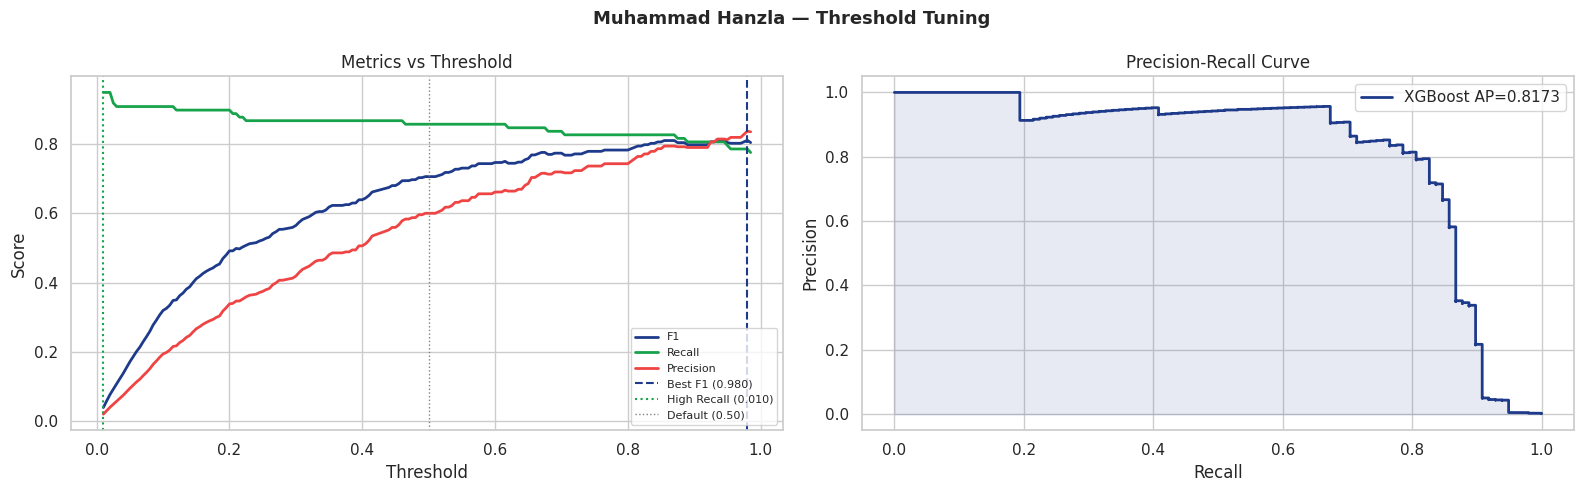

Threshold tuning saved ✅


In [12]:
# Tune threshold for XGBoost (best model)
thresholds   = np.arange(0.01, 0.99, 0.005)
f1_scores_th = [f1_score(y_test, (xgb_proba>=t).astype(int)) for t in thresholds]
recall_scores= []
prec_scores  = []
from sklearn.metrics import recall_score, precision_score
for t in thresholds:
    preds = (xgb_proba>=t).astype(int)
    recall_scores.append(recall_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))

best_f1_idx  = np.argmax(f1_scores_th)
best_thresh  = thresholds[best_f1_idx]
best_f1_val  = f1_scores_th[best_f1_idx]

# Choose threshold prioritising recall > 0.90
high_recall_idx = next((i for i,r in enumerate(recall_scores) if r >= 0.90), best_f1_idx)
recall_thresh   = thresholds[high_recall_idx]

print(f'Default  threshold (0.50) → F1={f1_score(y_test,(xgb_proba>=0.50).astype(int)):.4f}')
print(f'Best F1  threshold ({best_thresh:.3f}) → F1={best_f1_val:.4f}')
print(f'High recall threshold ({recall_thresh:.3f}) → Recall={recall_scores[high_recall_idx]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Muhammad Hanzla — Threshold Tuning', fontsize=13, fontweight='bold')

axes[0].plot(thresholds, f1_scores_th,  color='#1e3a8a', lw=2, label='F1')
axes[0].plot(thresholds, recall_scores, color='#16a34a', lw=2, label='Recall')
axes[0].plot(thresholds, prec_scores,   color='#ef4444', lw=2, label='Precision')
axes[0].axvline(best_thresh,  color='#1e3a8a', ls='--', label=f'Best F1 ({best_thresh:.3f})')
axes[0].axvline(recall_thresh,color='#16a34a', ls=':',  label=f'High Recall ({recall_thresh:.3f})')
axes[0].axvline(0.5, color='gray', ls=':', lw=1, label='Default (0.50)')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold'); axes[0].legend(fontsize=8)

prec_arr, rec_arr, _ = precision_recall_curve(y_test, xgb_proba)
axes[1].step(rec_arr, prec_arr, color='#1e3a8a', lw=2,
              where='post', label=f'XGBoost AP={xgb_ap:.4f}')
axes[1].fill_between(rec_arr, prec_arr, alpha=0.1, color='#1e3a8a', step='post')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig('04_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Threshold tuning saved ✅')

## 10. Full Evaluation — All Models

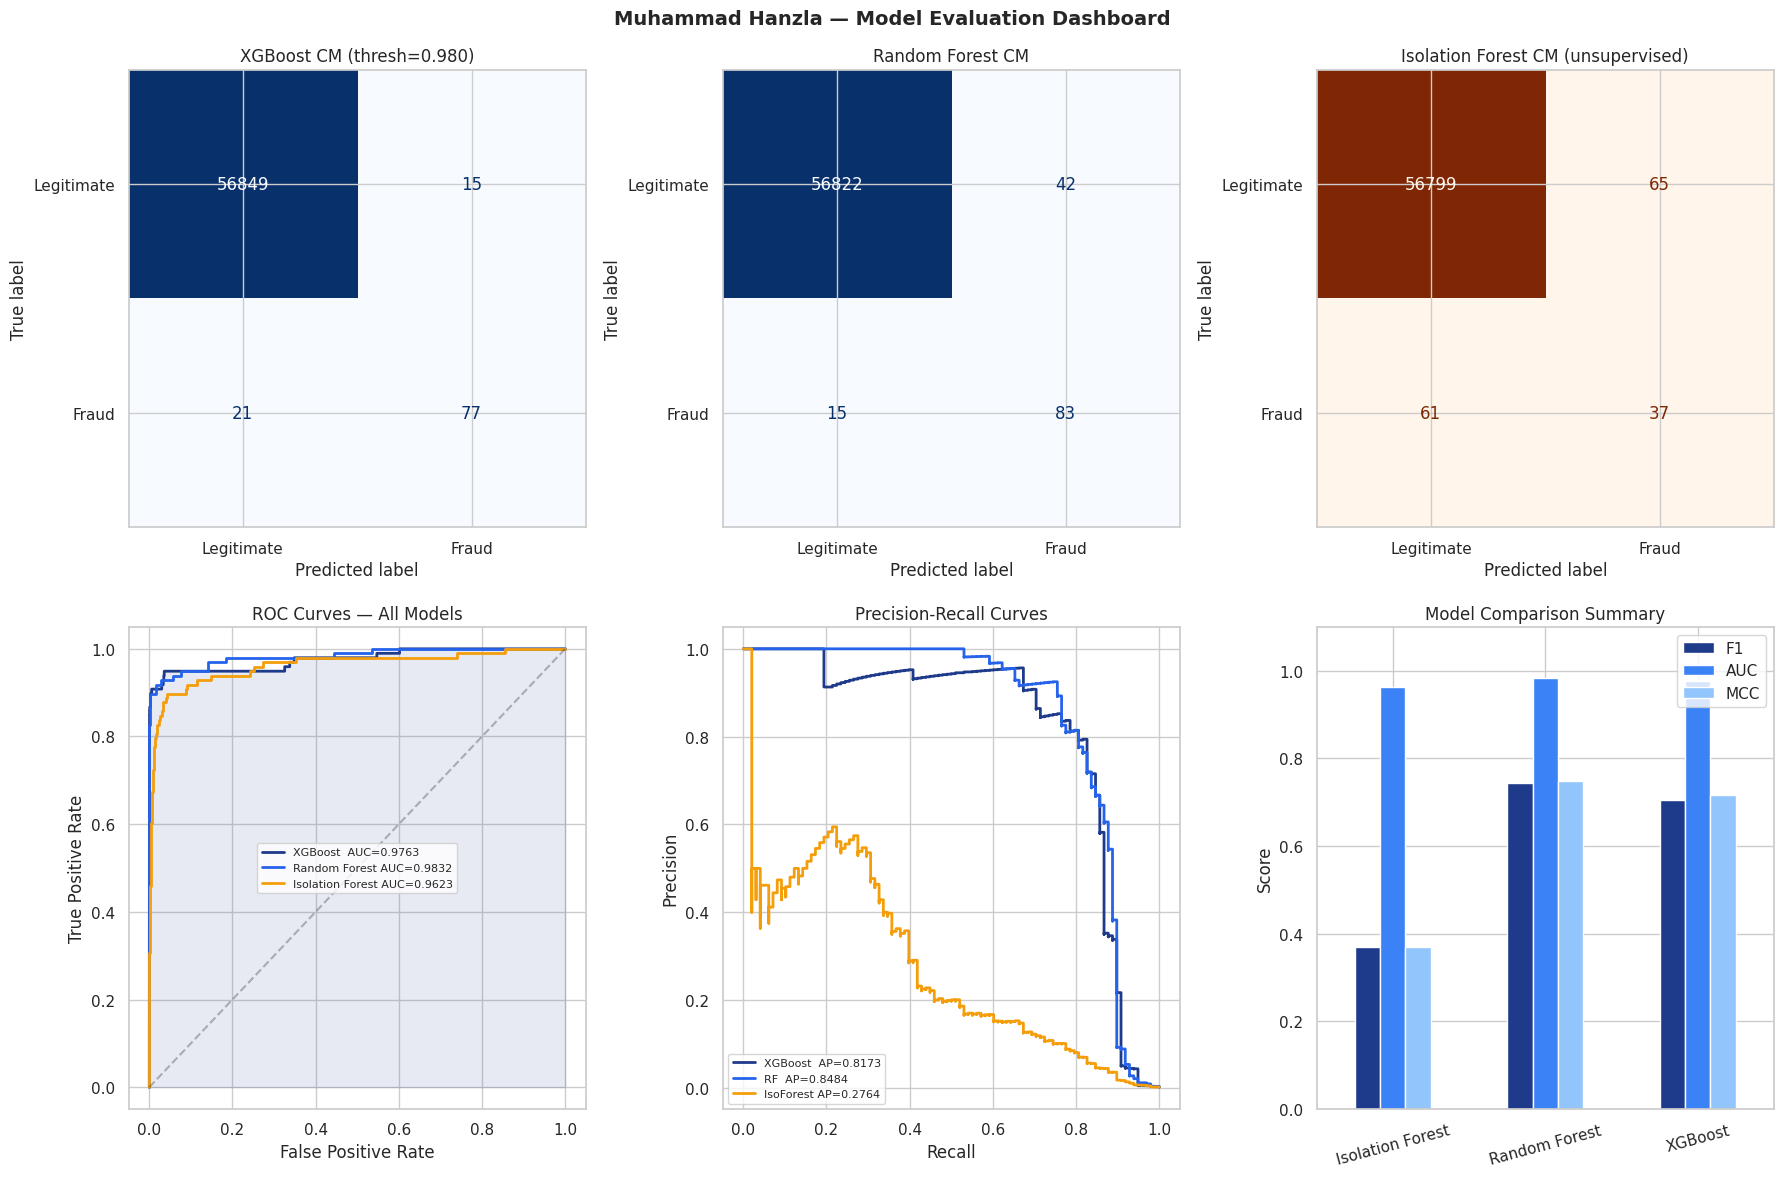

Evaluation dashboard saved ✅


In [13]:
best_preds  = (xgb_proba >= best_thresh).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Muhammad Hanzla — Model Evaluation Dashboard', fontsize=14, fontweight='bold')

# XGBoost Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds, ax=axes[0,0], colorbar=False, cmap='Blues',
    display_labels=['Legitimate','Fraud'])
axes[0,0].set_title(f'XGBoost CM (thresh={best_thresh:.3f})')

# RF Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=axes[0,1], colorbar=False, cmap='Blues',
    display_labels=['Legitimate','Fraud'])
axes[0,1].set_title('Random Forest CM')

# Isolation Forest CM
ConfusionMatrixDisplay.from_predictions(
    y_test, iso_preds, ax=axes[0,2], colorbar=False, cmap='Oranges',
    display_labels=['Legitimate','Fraud'])
axes[0,2].set_title('Isolation Forest CM (unsupervised)')

# ROC Curves
for preds, label, color in [
    (xgb_proba, f'XGBoost  AUC={xgb_auc:.4f}', '#1e3a8a'),
    (rf_proba,  f'Random Forest AUC={rf_auc:.4f}', '#2563eb'),
    (iso_scores,f'Isolation Forest AUC={iso_auc:.4f}', '#f59e0b'),
]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    axes[1,0].plot(fpr, tpr, lw=2, color=color, label=label)
axes[1,0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1,0].fill_between(*roc_curve(y_test, xgb_proba)[:2], alpha=0.1, color='#1e3a8a')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curves — All Models')
axes[1,0].legend(fontsize=8)

# Precision-Recall Comparison
for preds, label, color in [
    (xgb_proba, f'XGBoost  AP={xgb_ap:.4f}', '#1e3a8a'),
    (rf_proba,  f'RF  AP={rf_ap:.4f}',        '#2563eb'),
    (iso_scores,f'IsoForest AP={average_precision_score(y_test,iso_scores):.4f}','#f59e0b'),
]:
    p,r,_ = precision_recall_curve(y_test, preds)
    axes[1,1].step(r, p, lw=2, color=color, where='post', label=label)
axes[1,1].set_xlabel('Recall'); axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curves')
axes[1,1].legend(fontsize=8)

# Summary comparison table as bar chart
metrics_comparison = {
    'Isolation Forest': {'F1':iso_f1, 'AUC':iso_auc, 'MCC':iso_mcc},
    'Random Forest'   : {'F1':rf_f1,  'AUC':rf_auc,  'MCC':rf_mcc},
    'XGBoost'         : {'F1':xgb_f1, 'AUC':xgb_auc, 'MCC':xgb_mcc},
}
comp_df = pd.DataFrame(metrics_comparison).T
comp_df.plot(kind='bar', ax=axes[1,2],
              color=['#1e3a8a','#3b82f6','#93c5fd'],
              edgecolor='white')
axes[1,2].set_title('Model Comparison Summary')
axes[1,2].set_ylabel('Score')
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].legend()
axes[1,2].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('05_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation dashboard saved ✅')

## 11. SHAP Explainability — Why Did XGBoost Flag This Transaction?
SHAP (SHapley Additive exPlanations) shows which features pushed each prediction toward fraud.

Computing SHAP values (sample of 2000 transactions)...


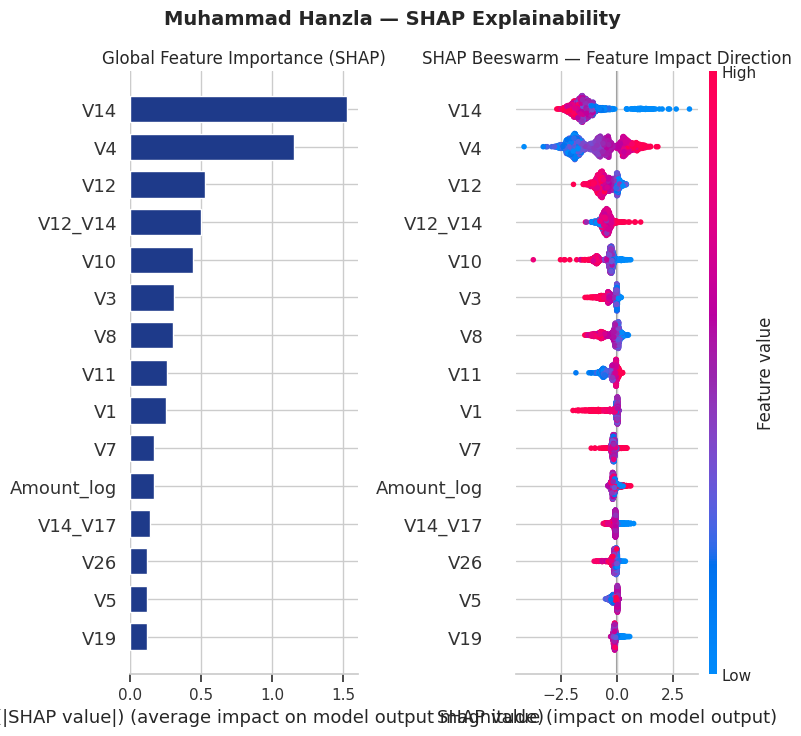

SHAP global plots saved ✅


In [14]:
print('Computing SHAP values (sample of 2000 transactions)...')
sample_idx   = np.random.choice(len(X_test_sc), size=2000, replace=False)
X_shap       = X_test_sc.iloc[sample_idx]

explainer    = shap.TreeExplainer(xgb)
shap_values  = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Muhammad Hanzla — SHAP Explainability', fontsize=14, fontweight='bold')

# Summary bar plot (global feature importance)
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                   show=False, max_display=15, color='#1e3a8a')
axes[0].set_title('Global Feature Importance (SHAP)')

# Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
axes[1].set_title('SHAP Beeswarm — Feature Impact Direction')

plt.tight_layout()
plt.savefig('06_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP global plots saved ✅')

Explaining fraud transaction #1109 in sample...
XGBoost probability: 0.9985


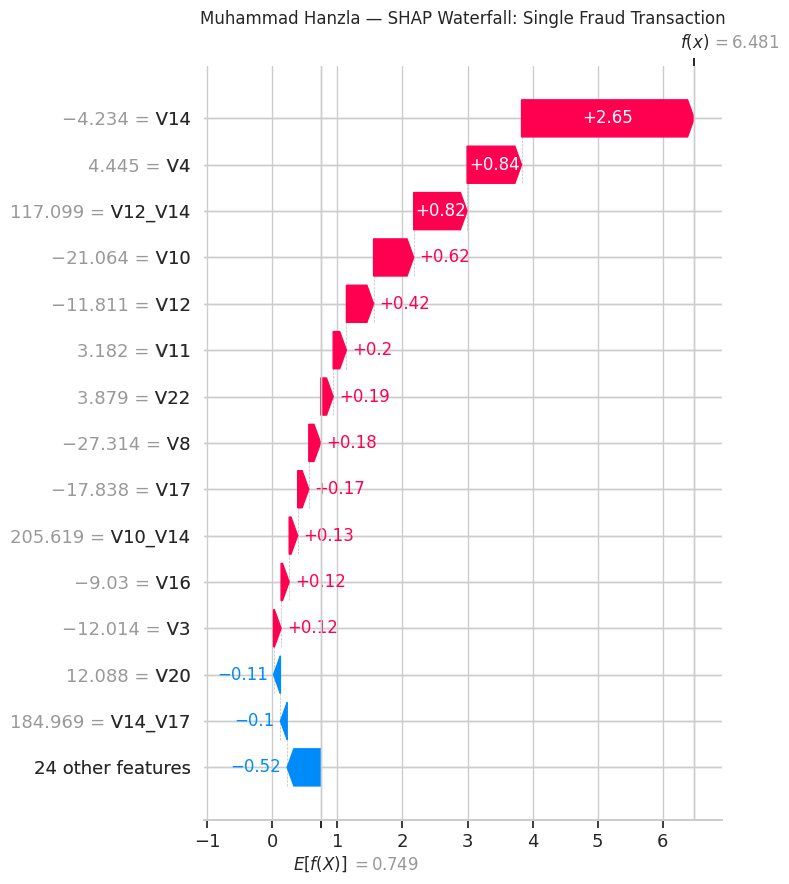

SHAP waterfall saved ✅


In [15]:
# SHAP Waterfall — explain a single fraud prediction
fraud_indices = np.where(y_test.values[sample_idx] == 1)[0]
if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    print(f'Explaining fraud transaction #{fraud_idx} in sample...')
    print(f'XGBoost probability: {xgb_proba[sample_idx[fraud_idx]]:.4f}')

    shap_exp = shap.Explanation(
        values          = shap_values[fraud_idx],
        base_values     = explainer.expected_value,
        data            = X_shap.iloc[fraud_idx],
        feature_names   = X_shap.columns.tolist()
    )
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title('Muhammad Hanzla — SHAP Waterfall: Single Fraud Transaction')
    plt.tight_layout()
    plt.savefig('07_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP waterfall saved ✅')
else:
    print('No fraud transactions in sample — increase sample size')

## 12. Business Impact Analysis
Translating model performance into **dollar value** — how much fraud does this model catch?

💰 Business Impact Analysis (Test Set Projection)
Total fraud transactions  : 98
Fraud CAUGHT (TP)         : 77  (78.6% recall)
Fraud MISSED (FN)         : 21
False alarms (FP)         : 15

Avg fraud amount          : $122.21
Fraud value caught        : $9,410
Fraud value missed        : $2,566
Investigation cost        : $1,380
NET SAVINGS               : $8,030


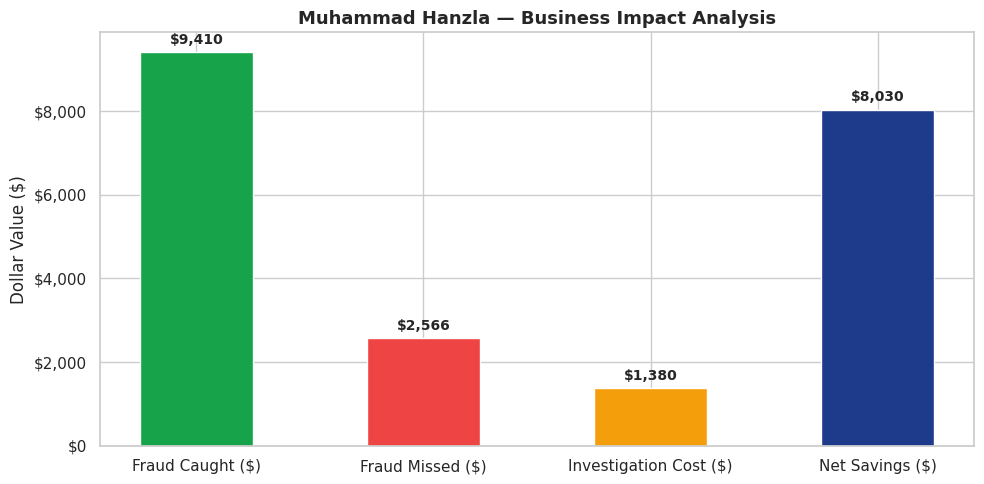

Business impact saved ✅


In [16]:
import matplotlib.ticker as mticker
# Assumptions
avg_fraud_amount = df[df['Class']==1]['Amount'].mean()
avg_investigation_cost = 15   # cost to investigate each flagged transaction ($)

cm = confusion_matrix(y_test, best_preds)
tn, fp, fn, tp = cm.ravel()

fraud_caught_value  = tp * avg_fraud_amount
fraud_missed_value  = fn * avg_fraud_amount
investigation_cost  = (tp + fp) * avg_investigation_cost
net_savings         = fraud_caught_value - investigation_cost

print('='*55)
print('💰 Business Impact Analysis (Test Set Projection)')
print('='*55)
print(f'Total fraud transactions  : {tp + fn}')
print(f'Fraud CAUGHT (TP)         : {tp}  ({tp/(tp+fn):.1%} recall)')
print(f'Fraud MISSED (FN)         : {fn}')
print(f'False alarms (FP)         : {fp}')
print()
print(f'Avg fraud amount          : ${avg_fraud_amount:.2f}')
print(f'Fraud value caught        : ${fraud_caught_value:,.0f}')
print(f'Fraud value missed        : ${fraud_missed_value:,.0f}')
print(f'Investigation cost        : ${investigation_cost:,.0f}')
print(f'NET SAVINGS               : ${net_savings:,.0f}')
print('='*55)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Fraud Caught ($)', 'Fraud Missed ($)', 'Investigation Cost ($)', 'Net Savings ($)']
values     = [fraud_caught_value, fraud_missed_value, investigation_cost, net_savings]
colors     = ['#16a34a', '#ef4444', '#f59e0b', '#1e3a8a']
bars = ax.bar(categories, values, color=colors, edgecolor='white', width=0.5)
ax.set_title('Muhammad Hanzla — Business Impact Analysis', fontsize=13, fontweight='bold')
ax.set_ylabel('Dollar Value ($)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.savefig('08_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Business impact saved ✅')

import matplotlib.ticker as mticker

## 13. Save Model & Scaler

In [17]:
import pickle

with open('fraud_xgb_model.pkl',  'wb') as f: pickle.dump(xgb, f)
with open('fraud_rf_model.pkl',   'wb') as f: pickle.dump(rf_pipe, f)
with open('fraud_scaler.pkl',     'wb') as f: pickle.dump(scaler, f)
with open('feature_names.pkl',    'wb') as f: pickle.dump(list(X.columns), f)

config = {
    'best_threshold': float(best_thresh),
    'xgb_auc'       : float(xgb_auc),
    'xgb_f1'        : float(xgb_f1),
    'xgb_ap'        : float(xgb_ap),
    'fraud_rate_pct' : fraud_pct
}
import json
with open('model_config.json', 'w') as f: json.dump(config, f, indent=2)

print('✅ Saved:')
print('   fraud_xgb_model.pkl   — XGBoost model')
print('   fraud_rf_model.pkl    — Random Forest pipeline')
print('   fraud_scaler.pkl      — RobustScaler')
print('   feature_names.pkl     — feature list')
print('   model_config.json     — thresholds & metrics')
print()
print('='*55)
print('✅ PROJECT COMPLETE — Muhammad Hanzla')
print('='*55)
print(f'  Dataset   : ULB Credit Card Fraud (284,807 txns)')
print(f'  Best model: XGBoost')
print(f'  AUC-ROC   : {xgb_auc:.4f}')
print(f'  Avg Prec  : {xgb_ap:.4f}')
print(f'  MCC       : {xgb_mcc:.4f}')
print(f'  Threshold : {best_thresh:.3f} (optimised)')
print(f'  Outputs   : 8 plots + SHAP + business impact')

✅ Saved:
   fraud_xgb_model.pkl   — XGBoost model
   fraud_rf_model.pkl    — Random Forest pipeline
   fraud_scaler.pkl      — RobustScaler
   feature_names.pkl     — feature list
   model_config.json     — thresholds & metrics

✅ PROJECT COMPLETE — Muhammad Hanzla
  Dataset   : ULB Credit Card Fraud (284,807 txns)
  Best model: XGBoost
  AUC-ROC   : 0.9763
  Avg Prec  : 0.8173
  MCC       : 0.7166
  Threshold : 0.980 (optimised)
  Outputs   : 8 plots + SHAP + business impact




<div style="background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%); padding: 30px; border-radius: 12px; text-align: center;">
<h3 style="color: #60a5fa;">Connect with Muhammad Hanzla</h3>
<p style="color: #94a3b8;">Feel free to reach out for collaboration, feedback, or opportunities!</p>
<div style="margin-top: 15px;">
<a href='mailto:muhammadhanzlaaltaf@gmail.com' style='color:#38bdf8; margin: 0 15px;'>📧 Email</a>
<a href='https://www.kaggle.com/muhammadhanzla1234' style='color:#38bdf8; margin: 0 15px;'>📊 Kaggle</a>
<a href='https://github.com/muhammadhanzlaaltaf' style='color:#38bdf8; margin: 0 15px;'>💻 GitHub</a>
<a href='https://www.linkedin.com/in/muhammad-hanzla-17a79237a/' style='color:#38bdf8; margin: 0 15px;'>💼 LinkedIn</a>
<a href='https://www.instagram.com/m.hanzlaaltaf/' style='color:#38bdf8; margin: 0 15px;'>📷 Instagram</a>
</div>
</div>